In [ ]:
# Q1: Install required libraries

!pip install pandas numpy scikit-learn nltk matplotlib seaborn kagglehub


   ---------------------------------------- 0/3 [pyyaml]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   -------------------------- ------------- 2/3 [kagglehub]
   -------------------------- ------------- 2/3 [kagglehub]
   -------------------------- ------------- 2/3 [kagglehub]
   ---------------------------------------- 3/3 [kagglehub]



In [2]:
# Q2: Import required libraries

import pandas as pd
import numpy as np
import re
import os
import pickle
import warnings

warnings.filterwarnings("ignore")

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Q3: Download required NLTK resources

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rmnav\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rmnav\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\rmnav\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rmnav\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
# Q4: Download Sentiment140 dataset

import kagglehub

path = kagglehub.dataset_download("kazanova/sentiment140")

files = os.listdir(path)

print("Dataset Path:", path)
print("Files:", files)

100%|██████████| 80.9M/80.9M [00:07<00:00, 11.9MB/s]

Extracting files...


Dataset Path: C:\Users\rmnav\.cache\kagglehub\datasets\kazanova\sentiment140\versions\2
Files: ['training.1600000.processed.noemoticon.csv']


In [5]:
# Q5: Load dataset into dataframe

csv_file = os.path.join(path, files[0])

columns = ['target','id','date','flag','user','text']

df_full = pd.read_csv(
    csv_file,
    encoding="latin-1",
    header=None,
    names=columns
)

df_full.head()

,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [6]:
# Q6: Select useful columns and clean dataset

df = df_full[['target','text']]

df.dropna(inplace=True)

df.drop_duplicates(inplace=True)

print("Dataset Shape:", df.shape)

Dataset Shape: (1583691, 2)


In [7]:
# Q7: Convert target labels into sentiment classes

df['sentiment'] = df['target'].apply(
    lambda x: "Positive" if x == 4 else "Negative"
)

df[['text','sentiment']].head()

,text,sentiment
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",Negative
1,is upset that he can't update his Facebook by ...,Negative
2,@Kenichan I dived many times for the ball. Man...,Negative
3,my whole body feels itchy and like its on fire,Negative
4,"@nationwideclass no, it's not behaving at all....",Negative


In [8]:
# Q8: Create balanced dataset to improve accuracy

df_pos = df[df['sentiment']=="Positive"].sample(150000, random_state=42)

df_neg = df[df['sentiment']=="Negative"].sample(150000, random_state=42)

df_sample = pd.concat([df_pos, df_neg])

print("Balanced Dataset Size:", df_sample.shape)

Balanced Dataset Size: (300000, 3)


In [9]:
# Q9: Prepare stopwords list

stop_words = set(stopwords.words('english'))

In [10]:
# Q10: Define text preprocessing function

def preprocess_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

In [11]:
# Q11: Apply preprocessing to dataset

df_sample['clean_text'] = df_sample['text'].apply(preprocess_text)

df_sample.head()

,target,text,sentiment,clean_text
1569660,4,Asshole!!! Its time for a bubble bath,Positive,asshole time bubble bath
896671,4,really hoping the homemade soup enough to take...,Positive,really hoping homemade soup enough take attent...
1491533,4,@Sundinska Your mail has been forwarded!,Positive,mail forwarded
1555710,4,first time ive even gotten a gift at someone e...,Positive,first time ive even gotten gift someone elses ...
1274077,4,"@mikeymcfly luv u, per usual. have great ment...",Positive,luv u per usual great mental day morr b inspired


In [12]:
# Q12: Convert text into TF-IDF features

tfidf = TfidfVectorizer(

    max_features = 60000,
    ngram_range = (1,2),
    min_df = 5,
    max_df = 0.9

)

X = tfidf.fit_transform(df_sample['clean_text'])

y = df_sample['sentiment']

In [13]:
# Q13: Split dataset into train and test sets

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y

)

In [14]:
  # Q14: Train Logistic Regression model

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [15]:
# Q15: Train Linear SVM model (best for text)

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [16]:
# Q16: Evaluate model accuracy

lr_pred = lr_model.predict(X_test)

svm_pred = svm_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

svm_acc = accuracy_score(y_test, svm_pred)

print("Logistic Regression Accuracy:", lr_acc)

print("SVM Accuracy:", svm_acc)

Logistic Regression Accuracy: 0.7827166666666666
SVM Accuracy: 0.7669666666666667


In [17]:
# Q17: Display classification report

print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

    Negative       0.78      0.75      0.76     30000
    Positive       0.76      0.78      0.77     30000

    accuracy                           0.77     60000
   macro avg       0.77      0.77      0.77     60000
weighted avg       0.77      0.77      0.77     60000



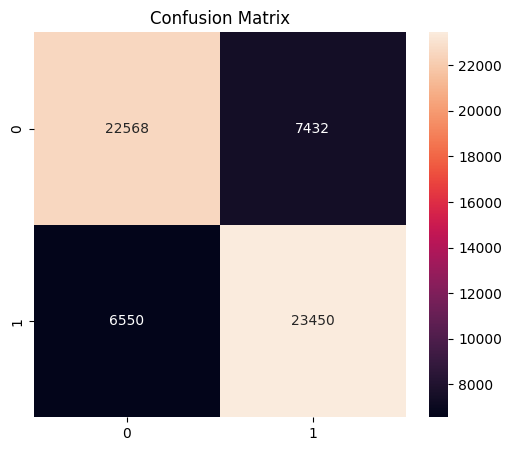

In [18]:
# Q18: Plot confusion matrix

cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.show()

In [19]:
# Q19: Predict sentiment for new text

def predict_sentiment(text):

    text = preprocess_text(text)

    vector = tfidf.transform([text])

    prediction = svm_model.predict(vector)

    return prediction[0]


predict_sentiment("The road condition in our area is very bad")

'Negative'

In [20]:
# Q20: Save trained model and vectorizer

pickle.dump(svm_model, open("sentiment_model.pkl","wb"))

pickle.dump(tfidf, open("tfidf_vectorizer.pkl","wb"))

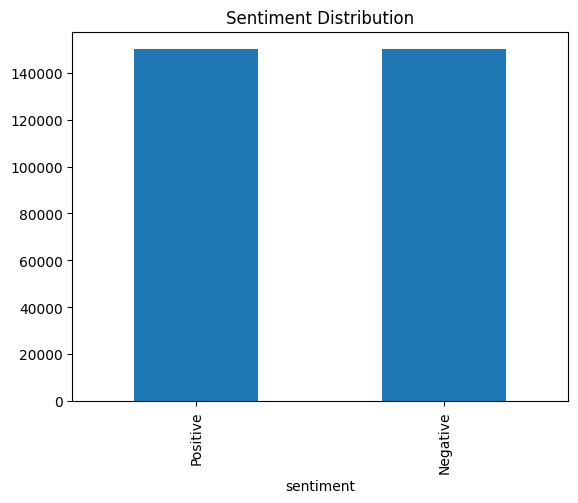

In [21]:
# Q21: Visualize sentiment distribution

df_sample['sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")

plt.show()